# Newtonian Identities (NI) Algorithm for DOA Estimation

[1] X. Heng, B. Tang, Z. Chen, Y. Yang, L. Chen, and Y. Sun, "Iterative covariance matrix reconstruction for sparse arrays using Newton's identities".Under review at IEEE Conference on Acoustics, Speech and Signal Processing (ICASSP2026).


This notebook implements the Newtonian Identities (NI) algorithm for DOA estimation and compares its performance with other SDP-based coarray reconstruction algorithms.

## Table of Contents
1. [NI Algorithm Implementation]()
2. [DOA Estimation Setup]()
3. [Performance Comparison]()
4. [Results Analysis]()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import doatools.model as model
import doatools.performance as perf
import doatools.plotting as plt_tools
import doatools.estimation as estimation
%matplotlib inline

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14, 
    'legend.fontsize': 14,
    'legend.loc': 'upper left',
    'legend.title_fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})
# 设置baseline固定marker和color: ANM\SPA\WDA\StructCovMLE\NI\DA\SS\CHankel\FastCHankel
plt_tools.set_doa_method_style('DA', color='cyan', marker='p')
# plt_tools.set_doa_method_style('SS', color='magenta', marker='h')
plt_tools.set_doa_method_style('ANM', color='orange', marker='+')
plt_tools.set_doa_method_style('SPA', color='blue', marker='D')
plt_tools.set_doa_method_style('WDA', color='green', marker='^')
plt_tools.set_doa_method_style('StructCovMLE', color='red', marker='*')
plt_tools.set_doa_method_style('NI', color='limegreen', marker='o')
plt_tools.set_doa_method_style('CHankel', color='darkred', marker='s')
plt_tools.set_doa_method_style('FastCHankel', color='darkkhaki', marker='X')
plt_tools.set_doa_method_style('NI+Beamforming', color='darkblue', marker='v')

# set global font and size


## 1. NI Algorithm Implementation <a name="ni-algorithm"></a>

In [2]:
from doatools.estimation import CovarianceReconstructionBase
from scipy.linalg import toeplitz, hankel, svd, norm, qr
from scipy.optimize import least_squares
import os
import torch
from sklearn.cluster import KMeans


class NewtonianIdentitiesRebutnessEstimator(CovarianceReconstructionBase):
    """Creates a source location estimator based on Newtonian Identities (NI) algorithm.

    The NI algorithm reconstructs the augmented covariance matrix using Newtonian identities
    to compute missing covariance elements from known ones.

    Args:
        array (~doatools.model.arrays.ArrayDesign): Array design.
        wavelength (float): Wavelength of the carrier wave.
        sigma_s2 (float, optional): Signal power. Defaults to 1.0.
        doa_estimator: DOA estimator instance. Defaults to None (RootMUSIC1D).
        search_grid (~doatools.estimation.grid.SearchGrid, optional): The search grid
            used to locate the sources. Defaults to None. Not needed for
            gridless DOA estimators like RootMUSIC1D and ESPRIT.
        **kwargs: Other keyword arguments.
    """
    def __init__(self, array, wavelength, sigma_s2: float = 1.0, doa_estimator=None, search_grid=None,enable_kmeans_init=True,**kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2
        self._array_name = array.name
        self._kmeans_anchors = None
        self.enable_kmeans_init = enable_kmeans_init
        if enable_kmeans_init:
            try:
                model_path = os.path.join("kmeans", self._array_name, f"ninn_model_{kwargs.get('k', 2)}.pth")
                if os.path.exists(model_path):
                    anchor_data = torch.load(model_path, weights_only=False)
                    self._kmeans_anchors = anchor_data['anchors']
                    print(f"Loaded Kmeans anchors from {model_path}")
                else:
                    print(f"Kmeans model not found at {model_path}, using default initialization")
            except Exception as e:
                print(f"Failed to load Kmeans anchors: {e}")
                self._kmeans_anchors = None

    @staticmethod
    def _compute_elementary_symmetric_polynomials(p: np.ndarray, k: int) -> np.ndarray:
        """使用牛顿恒等式计算基本对称多项式 e_1, e_2, ..., e_k。

        Args:
            p: 已知的幂和数组 [p_1, p_2, ..., p_k]，支持复数。
            k: 变量个数。

        Returns:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]。
        """
        e = np.zeros(k + 1, dtype=complex)
        e[0] = 1
        for n in range(1, k + 1):
            sum_term = 0
            for j in range(1, n + 1):
                if j - 1 < len(p):
                    sum_term += (-1) ** (j - 1) * e[n - j] * p[j - 1]
            e[n] = sum_term / n
        return e[1:]

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        """使用牛顿恒等式和给定的e计算幂和 p_1 到 p_m。

        Args:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]
            k: 变量个数
            m: 最大幂次
        Returns:
            p_array: 幂和数组 [p_1, p_2, ..., p_m]，索引从0开始对应p_1到p_m
        """
        p_array = np.zeros(m, dtype=complex)
        for n in range(1, m + 1):
            if n <= k:
                p_n = 0
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
                p_n += (-1) ** (n - 1) * n * e[n - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n

        return p_array

    def _compute_missing_R(self, k: int, m: int, known_p: np.ndarray, known_indices: np.ndarray,
                           sigma_s2: complex = 1.0, best_e_initial: np.ndarray = None) -> np.ndarray:
        """计算缺失的 R_{n,1} 值。

        Args:
            k: 变量个数
            m: 方程总数（最大幂次）
            known_p: 已知的 R_{n,0} 值数组，形状为 (len(known_indices),)
            known_indices: 已知值的索引数组，形状为 (len(known_p),)
            sigma_s2: 信号功率的平方
            best_e_initial: 从Kmeans锚点获取的初始e值，可选

        Returns:
            missing_R: 缺失的 R_{n,0} 值数组，形状为 (m,)
        """
        if len(known_indices) < k:
            raise ValueError(f"需要至少 {k} 个已知的 R值，但只提供了 {len(known_indices)} 个。")
        known_p_normalized = known_p / sigma_s2
        e_initial = np.zeros(k, dtype=complex)
        if best_e_initial is not None:
            e_initial = best_e_initial[:k] if len(best_e_initial) >= k else best_e_initial
            if len(e_initial) < k:
                e_initial = np.pad(e_initial, (0, k - len(e_initial)), 'constant')
        else:
            for i in range(k, 0, -1):
                if np.isin(np.arange(1, i + 1), known_indices).all():
                    mask = np.isin(known_indices, np.arange(1, i + 1))
                    if np.sum(mask) == i:
                        selected_p = known_p_normalized[mask]
                        e_initial[:i] = self._compute_elementary_symmetric_polynomials(selected_p, i)
                        break
        x0 = np.zeros(2 * k)
        x0[:k] = np.real(e_initial)
        x0[k:] = np.imag(e_initial)
        def residual_function(x: np.ndarray, known_p_norm: np.ndarray, known_idx: np.ndarray, k: int,
                              max_n: int) -> np.ndarray:
            e_real = x[:k]
            e_imag = x[k:]
            e = e_real + 1j * e_imag
            p_array = self._compute_power_sums_from_e(e, k, max_n)
            residuals = []
            for i, n in enumerate(known_idx):
                if n > max_n:
                    continue
                pred_val = p_array[n - 1]
                true_val = known_p_norm[i]
                diff = (pred_val - true_val)
                residuals.append(np.real(diff))
                residuals.append(np.imag(diff))
            return np.array(residuals)
        max_known = np.max(known_indices)
        res = least_squares(
            residual_function, x0,
            args=(known_p_normalized, known_indices, k, max_known),
            method='lm',
            ftol=1e-8,
            xtol=1e-8,
            max_nfev=1000,
        )
        x_opt = res.x
        e_opt = x_opt[:k] + 1j * x_opt[k:]
        p_array = self._compute_power_sums_from_e(e_opt, k, m)
        return sigma_s2 * p_array

    def reconstruct(self, R, **kwargs):
        """Reconstructs the augmented covariance matrix using Newtonian Identities algorithm.

        Args:
            R (~numpy.ndarray): Sample covariance matrix of the sparse array.

        Returns:
            ~numpy.ndarray: Augmented covariance matrix.
        """
        scm_vector = self._coarray_builder.transform(R, 'da')
        return scm_vector

    # Override the estimate method to use the correct NI algorithm flow
    def estimate(self, R, k, **kwargs):
        """Estimates the source locations from the given covariance matrix using NI algorithm.

        Args:
            R (~numpy.ndarray): Covariance matrix input. The size of R must
                match that of the array design used when creating this
                estimator.
            k (int): Expected number of sources.
            **kwargs: Other keyword arguments.

        Returns:
            A tuple with the following elements.

            * resolved (:class:`bool`): ``True`` if the desired number of
              sources are found. This flag does **not** guarantee that the
              estimated source locations are correct. The estimated source
              locations may be completely wrong!
              If resolved is False, both ``estimates`` and ``spectrum`` will be
              ``None``.
            * estimates (:class:`~doatools.model.sources.SourcePlacement`):
              A :class:`~doatools.model.sources.SourcePlacement` instance of the
              same type as the one used in the search grid (if provided),
              representing the estimated source locations. Will be ``None`` if resolved is
              ``False``.
            * spectrum (:class:`~numpy.ndarray`): An numpy array of the same
              shape of the specified search grid, consisting of values evaluated
              at the grid points. Only present if ``return_spectrum`` is
              ``True`` and a search grid is provided.
        """
        _, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        non_zero_mask = scm_vector[1:] != 0.0
        known_indices = np.where(non_zero_mask)[0] + 1
        known_values = scm_vector[known_indices]
        
        best_e_initial = None
        if self._kmeans_anchors:
            try:
                min_distance = float('inf')
                for anchor_p, anchor_e in self._kmeans_anchors:
                    distance = np.linalg.norm(scm_vector[1:] - anchor_p[1:])
                    if distance < min_distance:
                        min_distance = distance
                        best_e_initial = anchor_e
            except Exception as e:
                print(f"Failed to select initial e from Kmeans anchors: {e}")
                best_e_initial = None
        try:
            # print(best_e_initial)
            all_R_values = self._compute_missing_R(k, m - 1, known_values, known_indices, self._sigma_s2, best_e_initial)
            scm_vector[1:m] = all_R_values
            Ra = toeplitz(scm_vector)
        except Exception as e:
            print(f"NI algorithm failed: {e}")
            Ra = toeplitz(scm_vector)
            Ra = (Ra + Ra.conj().T) / 2
        return self._doa_estimate(Ra, k, **kwargs)


class NewtonianIdentitiesEstimator(CovarianceReconstructionBase):
    """Creates a source location estimator based on Newtonian Identities (NI) algorithm.

    The NI algorithm reconstructs the augmented covariance matrix using Newtonian identities
    to compute missing covariance elements from known ones.

    Args:
        array (~doatools.model.arrays.ArrayDesign): Array design.
        wavelength (float): Wavelength of the carrier wave.
        sigma_s2 (float, optional): Signal power. Defaults to 1.0.
        doa_estimator: DOA estimator instance. Defaults to None (RootMUSIC1D).
        search_grid (~doatools.estimation.grid.SearchGrid, optional): The search grid
            used to locate the sources. Defaults to None. Not needed for
            gridless DOA estimators like RootMUSIC1D and ESPRIT.
        **kwargs: Other keyword arguments.
    """

    def __init__(self, array, wavelength, sigma_s2: float = 1.0, doa_estimator=None, search_grid=None, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2

    @staticmethod
    def _compute_elementary_symmetric_polynomials(p: np.ndarray, k: int) -> np.ndarray:
        """使用牛顿恒等式计算基本对称多项式 e_1, e_2, ..., e_k。

        Args:
            p: 已知的幂和数组 [p_1, p_2, ..., p_k]，支持复数。
            k: 变量个数。

        Returns:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]。
        """
        e = np.zeros(k + 1, dtype=complex)
        e[0] = 1
        for n in range(1, k + 1):
            sum_term = 0
            for j in range(1, n + 1):
                if j - 1 < len(p):
                    sum_term += (-1) ** (j - 1) * e[n - j] * p[j - 1]
            e[n] = sum_term / n
        return e[1:]

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        """使用牛顿恒等式和给定的e计算幂和 p_1 到 p_m。

        Args:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]
            k: 变量个数
            m: 最大幂次

        Returns:
            p_array: 幂和数组 [p_1, p_2, ..., p_m]，索引从0开始对应p_1到p_m
        """
        p_array = np.zeros(m, dtype=complex)

        for n in range(1, m + 1):
            if n <= k:
                p_n = 0
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
                p_n += (-1) ** (n - 1) * n * e[n - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n

        return p_array

    def _compute_missing_R(self, k: int, m: int, known_p: np.ndarray, known_indices: np.ndarray,
                           sigma_s2: complex = 1.0) -> np.ndarray:
        """计算缺失的 R_{n,1} 值。

        Args:
            k: 变量个数
            m: 方程总数（最大幂次）
            known_p: 已知的 R_{n,0} 值数组，形状为 (len(known_indices),)
            known_indices: 已知值的索引数组，形状为 (len(known_p),)
            sigma_s2: 信号功率的平方

        Returns:
            missing_R: 缺失的 R_{n,0} 值数组，形状为 (m,)
        """
        if len(known_indices) < k:
            raise ValueError(f"需要至少 {k} 个已知的 R值，但只提供了 {len(known_indices)} 个。")

        # 归一化已知值
        known_p_normalized = known_p / sigma_s2

        # 设置初始值e
        e_initial = np.zeros(k, dtype=complex)
        for i in range(k, 0, -1):
            if np.isin(np.arange(1, i + 1), known_indices).all():
                # 找到连续的索引
                mask = np.isin(known_indices, np.arange(1, i + 1))
                if np.sum(mask) == i:
                    selected_p = known_p_normalized[mask]
                    e_initial[:i] = self._compute_elementary_symmetric_polynomials(selected_p, i)
                    break

        # 将复数e转换为实数向量 [实部, 虚部]
        x0 = np.zeros(2 * k)
        x0[:k] = np.real(e_initial)
        x0[k:] = np.imag(e_initial)

        # 定义残差函数
        def residual_function(x: np.ndarray, known_p_norm: np.ndarray, known_idx: np.ndarray, k: int,
                              max_n: int) -> np.ndarray:
            """计算残差：预测值与已知值的差异"""
            # 将实数向量转换为复数e
            e_real = x[:k]
            e_imag = x[k:]
            e = e_real + 1j * e_imag

            # 使用当前e计算所有幂和
            p_array = self._compute_power_sums_from_e(e, k, max_n)

            residuals = []
            for i, n in enumerate(known_idx):
                if n > max_n:
                    continue
                pred_val = p_array[n - 1]
                true_val = known_p_norm[i]
                diff = (pred_val - true_val)
                residuals.append(np.real(diff))  # 实部残差
                residuals.append(np.imag(diff))  # 虚部残差

            return np.array(residuals)

        # 最大已知索引
        max_known = np.max(known_indices)

        # 使用最小二乘和Levenberg-Marquardt方法超定方程组
        res = least_squares(
            residual_function, x0,
            args=(known_p_normalized, known_indices, k, max_known),
            method='lm',
            ftol=1e-8,  # 函数容忍度
            xtol=1e-8,  # 参数容忍度
            max_nfev=1000,  # 最大函数评估次数
        )

        # 提取优化后的e
        x_opt = res.x
        e_opt = x_opt[:k] + 1j * x_opt[k:]

        # 使用优化后的e计算所有幂和
        p_array = self._compute_power_sums_from_e(e_opt, k, m)

        # 返回所有幂和（包括已知和缺失的）
        return sigma_s2 * p_array

    def reconstruct(self, R, **kwargs):
        """Reconstructs the augmented covariance matrix using Newtonian Identities algorithm.

        Args:
            R (~numpy.ndarray): Sample covariance matrix of the sparse array.

        Returns:
            ~numpy.ndarray: Augmented covariance matrix.
        """
        scm_vector = self._coarray_builder.transform(R, 'da')
        return scm_vector

    # Override the estimate method to use the correct NI algorithm flow
    def estimate(self, R, k, **kwargs):
        """Estimates the source locations from the given covariance matrix using NI algorithm.

        Args:
            R (~numpy.ndarray): Covariance matrix input. The size of R must
                match that of the array design used when creating this
                estimator.
            k (int): Expected number of sources.
            **kwargs: Other keyword arguments.

        Returns:
            A tuple with the following elements.

            * resolved (:class:`bool`): ``True`` if the desired number of
              sources are found. This flag does **not** guarantee that the
              estimated source locations are correct. The estimated source
              locations may be completely wrong!
              If resolved is False, both ``estimates`` and ``spectrum`` will be
              ``None``.
            * estimates (:class:`~doatools.model.sources.SourcePlacement`):
              A :class:`~doatools.model.sources.SourcePlacement` instance of the
              same type as the one used in the search grid (if provided),
              representing the estimated source locations. Will be ``None`` if resolved is
              ``False``.
            * spectrum (:class:`~numpy.ndarray`): An numpy array of the same
              shape of the specified search grid, consisting of values evaluated
              at the grid points. Only present if ``return_spectrum`` is
              ``True`` and a search grid is provided.
        """
        n, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        non_zero_mask = scm_vector[1:] != 0.0
        known_indices = np.where(non_zero_mask)[0] + 1
        known_values = scm_vector[known_indices]
        try:
            all_R_values = self._compute_missing_R(k, m - 1, known_values, known_indices, self._sigma_s2)
            scm_vector[1:m] = all_R_values
            Ra = toeplitz(scm_vector)
        except Exception as e:
            print(f"NI algorithm failed: {e}")
            Ra = toeplitz(scm_vector)
            Ra = (Ra + Ra.conj().T) / 2
        return self._doa_estimate(Ra, k, **kwargs)


from scipy.signal import find_peaks

from doatools.estimation import CovarianceReconstructionBase
from scipy.linalg import toeplitz
from scipy.optimize import least_squares
from scipy.signal import find_peaks
import numpy as np

class NewtonianIdentitiesBeamformingEstimator(CovarianceReconstructionBase):
    """基于牛顿恒等式 + 确定性粗波束形成，联合估计信号功率 σ_s² 和初值 e"""

    def __init__(self, array, wavelength, sigma_s2: float = 1.0,
                 doa_estimator=None, search_grid=None,
                 beamforming_grid_size=1800, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2          # 仅作为 fallback，实际会被估计覆盖
        self._bf_grid_size = beamforming_grid_size
        self._d_lambda = 0.5
        self.estimated_sigma_s2 = None     # 新增：运行后可访问真实估计值

    @staticmethod
    def _compute_elementary_symmetric_polynomials(p: np.ndarray, k: int) -> np.ndarray:
        e = np.zeros(k + 1, dtype=complex)
        e[0] = 1
        for n in range(1, k + 1):
            sum_term = 0
            for j in range(1, n + 1):
                if j - 1 < len(p):
                    sum_term += (-1) ** (j - 1) * e[n - j] * p[j - 1]
            e[n] = sum_term / n
        return e[1:]

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        p_array = np.zeros(m, dtype=complex)
        for n in range(1, m + 1):
            if n <= k:
                p_n = (-1) ** (n - 1) * n * e[n - 1]
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n
        return p_array

    def _angles_to_e(self, angles, k):
        zs = np.exp(1j * 2 * np.pi * self._d_lambda * np.sin(angles))
        coeffs = np.poly(zs)
        e_vec = np.zeros(k, dtype=complex)
        for n in range(1, k + 1):
            e_vec[n-1] = coeffs[n] * ((-1)**n)
        return e_vec

    def _get_initial_guess(self, k, known_p, known_indices):
        """波束形成 + 线性LS，同时给出 e_init 和 sigma_init（关键改进）"""
        grid = np.linspace(-np.pi/2, np.pi/2, self._bf_grid_size)
        mu = 2 * np.pi * self._d_lambda * np.sin(grid)
        exponents = np.exp(-1j * np.outer(known_indices, mu))
        spectrum = np.real(known_p @ exponents)

        # 改进寻峰：避免相邻重复峰
        peaks, _ = find_peaks(spectrum, distance=max(3, len(grid)//100))
        if len(peaks) >= k:
            top_idx = np.argsort(spectrum[peaks])[-k:]
            selected_angles = grid[peaks[top_idx]]
        else:
            selected_angles = grid[np.argsort(spectrum)[-k:]]

        e_init = self._angles_to_e(selected_angles, k)

        # 用初始 e 做线性LS求 sigma_init（极快且准）
        max_known = int(np.max(known_indices))
        p_init = self._compute_power_sums_from_e(e_init, k, max_known)
        p_known_init = p_init[known_indices - 1]
        denom = np.sum(np.abs(p_known_init)**2)
        if denom > 1e-12:
            num = np.dot(known_p, np.conj(p_known_init))
            sigma_init = max(np.real(num / denom), 1e-6)
        else:
            sigma_init = 1.0
        return e_init, sigma_init

    def _compute_missing_R(self, k: int, m: int, known_p: np.ndarray, known_indices: np.ndarray):
        """联合优化 e 和 σ_s²，返回 (补全的R, estimated_sigma)"""
        max_known = int(np.max(known_indices))

        # 1. 优质初值（波束形成 + 线性LS）
        e_init, sigma_init = self._get_initial_guess(k, known_p, known_indices)

        # 2. 优化变量： [Re(e), Im(e), sigma]
        x0 = np.zeros(2 * k + 1)
        x0[:k] = np.real(e_init)
        x0[k:2*k] = np.imag(e_init)
        x0[-1] = sigma_init

        def residual_function(x):
            e = x[:k] + 1j * x[k:2*k]
            sigma = max(x[-1], 1e-8)                     # 安全保护
            p_array = self._compute_power_sums_from_e(e, k, max_known)
            pred = sigma * p_array[known_indices - 1]
            diff = pred - known_p
            return np.concatenate([np.real(diff), np.imag(diff)])

        # 3. 优化（trf 支持 bounds）
        lb = np.full(2*k + 1, -np.inf)
        lb[-1] = 1e-8
        ub = np.full(2*k + 1, np.inf)
        res = least_squares(residual_function, x0, bounds=(lb, ub),
                            method='trf', ftol=1e-12, xtol=1e-12,
                            gtol=1e-12, max_nfev=2000)

        # 4. 提取结果
        x_opt = res.x
        e_opt = x_opt[:k] + 1j * x_opt[k:2*k]
        sigma_est = max(x_opt[-1], 1e-8)

        p_full = self._compute_power_sums_from_e(e_opt, k, m)
        return sigma_est * p_full, sigma_est

    def reconstruct(self, R, **kwargs):
        return self._coarray_builder.transform(R, 'da')

    def estimate(self, R, k, **kwargs):
        _, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        non_zero_mask = scm_vector[1:] != 0.0
        known_indices = np.where(non_zero_mask)[0] + 1
        known_values = scm_vector[known_indices]

        try:
            all_R_values, sigma_est = self._compute_missing_R(
                k, m - 1, known_values, known_indices)
            scm_vector[1:m] = all_R_values
            self.estimated_sigma_s2 = sigma_est          # <-- 暴露给用户
        except Exception as e:
            print(f"NI-BF 算法失败: {e}")
            self.estimated_sigma_s2 = self._sigma_s2

        Ra = toeplitz(scm_vector)
        Ra = (Ra + Ra.conj().T) / 2
        return self._doa_estimate(Ra, k, **kwargs)

class CadzowHankelEstimator(CovarianceReconstructionBase):
    """
    基于 Cadzow 迭代（硬阈值与结构化低秩逼近）的协方差矩阵补全算法。
    
    相比于核范数最小化（软阈值），该方法利用已知的信源数 k 进行硬截断，
    消除了高 SNR 下的收缩偏差，能够更好地贴近 CRLB。

    Args:
        array: 阵列设计。
        wavelength: 波长。
        max_iter (int): 最大迭代次数。
        tol (float): 收敛阈值。
        enforce_psd (bool): 是否在最后强制正定性。
        doa_estimator: DOA 估计器。
    """

    def __init__(self, array, wavelength, max_iter: int = 500, tol: float = 1e-6, 
                 enforce_psd: bool = False, doa_estimator=None, search_grid=None, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._max_iter = max_iter
        self._tol = tol
        self._enforce_psd = enforce_psd

    @staticmethod
    def _hard_threshold(M: np.ndarray, k: int) -> np.ndarray:
        """硬阈值算子：仅保留前 k 个最大的奇异值，其余置零。
        这是去偏的关键步骤。
        """
        U, s, Vh = svd(M, full_matrices=False)
        
        # 构建低秩近似
        # 只保留前 k 个分量
        s_k = s[:k]
        U_k = U[:, :k]
        Vh_k = Vh[:k, :]
        
        return (U_k * s_k) @ Vh_k

    @staticmethod
    def _average_antidiagonals(Z: np.ndarray, N: int) -> np.ndarray:
        """对矩阵的反对角线进行平均，强制其变为汉克尔结构对应的向量。
        """
        L1, L2 = Z.shape
        v = np.zeros(N, dtype=Z.dtype)
        count = np.zeros(N)
        
        for i in range(L1):
            for j in range(L2):
                idx = i + j
                if idx < N:
                    v[idx] += Z[i, j]
                    count[idx] += 1
                    
        return v / np.maximum(count, 1)

    def _solve_cadzow(self, r_obs: np.ndarray, known_mask: np.ndarray, k: int) -> np.ndarray:
        """执行 Cadzow 迭代 (POCS) 进行补全。
        
        Args:
            r_obs: 观测到的协方差向量（缺失处为0或其他值）。
            known_mask: 布尔掩码，True 表示该位置是物理观测值。
            k: 信号源数量（秩）。
        """
        N = len(r_obs)
        L1 = (N + 1) // 2
        L2 = N + 1 - L1
        
        # 初始化：缺失值可以用 0 填充，或者用已有数据的插值
        x = r_obs.copy()
        
        prev_x = np.zeros_like(x)
        
        for i in range(self._max_iter):
            # 1. 构造汉克尔矩阵
            H = hankel(x[:L1], x[L1-1:])
            
            # 2. 投影到低秩流形 (Rank-K Hard Thresholding)
            #    这里强制秩为 k，消除了噪声且不收缩信号幅度
            H_low = self._hard_threshold(H, k)
            
            # 3. 投影到汉克尔结构 (Averaging)
            x_recon = self._average_antidiagonals(H_low, N)
            
            # 4. 投影到数据一致性 (Data Consistency)
            #    对于已知的位置，我们强制它等于观测值（或者保留观测值的主导地位）
            #    这是 POCS 的关键：在“低秩性”和“观测一致性”之间反复投影
            x_next = x_recon.copy()
            x_next[known_mask] = r_obs[known_mask]
            
            # 检查收敛
            diff = np.linalg.norm(x_next - x) / np.linalg.norm(x_next)
            if diff < self._tol:
                x = x_next
                break
                
            x = x_next
            
        return x

    def reconstruct(self, R, **kwargs):
        # Base class method override usually takes just R
        # But we need k, which is usually passed in estimate.
        # So we will just do the transformation here.
        return self._coarray_builder.transform(R, 'da')

    def estimate(self, R, k, **kwargs):
        """
        Estimates source locations.
        Args:
            R: Covariance matrix.
            k: Number of sources (CRITICAL for Hard Thresholding).
        """
        # 1. 获取差分阵列向量
        scm_vector_full = self.reconstruct(R)[:, 0]
        m = scm_vector_full.shape[0]
        
        # 提取第一个元素（只包含信号功率信息，不包含角度信息）
        scm_vector_0 = scm_vector_full[0]
        
        # 只处理 [1:] 之后的元素
        scm_vector_part = scm_vector_full[1:]
        
        # 2. 识别已知元素 (非零元素)，对应调整掩码
        #    假设输入 R 是稀疏阵列的协方差，未命中的差分滞后为 0
        non_zero_mask_part = np.abs(scm_vector_part) > 1e-10
        
        # 3. 执行 Cadzow 补全，只处理 [1:] 部分
        try:
            # 核心改进：传入 k 进行硬阈值处理
            reconstructed_part = self._solve_cadzow(scm_vector_part, non_zero_mask_part, k)
            
            # 4. 拼接回第一个元素
            reconstructed_x = np.concatenate([[scm_vector_0], reconstructed_part])
            
            # 5. 构造 Toeplitz
            reconstructed_x[0] = np.real(reconstructed_x[0])
            Ra = toeplitz(reconstructed_x)
            
            # (可选) 强制正定性，有时能进一步稳定低 SNR
            if self._enforce_psd:
                vals, vecs = np.linalg.eigh(Ra)
                vals[vals < 0] = 0
                Ra = vecs @ np.diag(vals) @ vecs.T.conj()

        except Exception as e:
            print(f"Cadzow algorithm failed: {e}")
            # Fallback
            Ra = toeplitz(scm_vector_full)
            Ra = (Ra + Ra.conj().T) / 2

        return self._doa_estimate(Ra, k, **kwargs)


from doatools.estimation import CovarianceReconstructionBase, RootMUSIC1D, MUSIC
from scipy.linalg import toeplitz
from scipy.signal import find_peaks
import numpy as np
import torch
import os

class BeamformingEstimator(CovarianceReconstructionBase):
    """
    【消融实验专用】Beamforming Baseline
    仅使用确定性的粗波束形成 (Coarse Beamforming) 进行协方差重建。
    最终使用 Root-MUSIC 在重建的虚拟ULA上进行DOA估计。
    """

    def __init__(self, array, wavelength, sigma_s2: float = 1.0, doa_estimator=None, 
                 search_grid=None, beamforming_grid_size=1800, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2
        self._bf_grid_size = beamforming_grid_size
        self._d_lambda = 0.5  # 假设半波长间距

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        """用于从 e 恢复完整的协方差序列 p"""
        p_array = np.zeros(m, dtype=complex)
        for n in range(1, m + 1):
            if n <= k:
                p_n = 0
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
                p_n += (-1) ** (n - 1) * n * e[n - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n
        return p_array

    def _angles_to_e(self, angles, k):
        """将角度转换为基本对称多项式系数 e"""
        zs = np.exp(1j * 2 * np.pi * self._d_lambda * np.sin(angles))
        coeffs = np.poly(zs)
        e_vec = np.zeros(k, dtype=complex)
        for n in range(1, k + 1):
            e_vec[n-1] = coeffs[n] * ((-1)**n)
        return e_vec

    def reconstruct(self, R, **kwargs):
        scm_vector = self._coarray_builder.transform(R, 'da')
        return scm_vector

    def estimate(self, R, k, **kwargs):
        _, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        
        # 1. 提取已知元素
        non_zero_mask = scm_vector[1:] != 0.0
        known_indices = np.where(non_zero_mask)[0] + 1
        known_values = scm_vector[known_indices]

        # 2. 网格搜索 (Beamforming Initialization)
        grid = np.linspace(-np.pi/2, np.pi/2, self._bf_grid_size)
        mu = 2 * np.pi * self._d_lambda * np.sin(grid)
        exponents = np.exp(-1j * np.outer(known_indices, mu))
        
        # 计算粗略谱
        positive_part = known_values @ exponents
        spectrum_bf = np.real(positive_part)
        
        # 寻峰
        peaks, _ = find_peaks(spectrum_bf)
        if len(peaks) > 0:
            peak_heights = spectrum_bf[peaks]
            sorted_indices = np.argsort(peak_heights)[::-1]
            top_indices = sorted_indices[:k]
            initial_angles = grid[peaks[top_indices]]
        else:
            sorted_indices = np.argsort(spectrum_bf)[::-1]
            initial_angles = grid[sorted_indices[:k]]

        # 补齐
        if len(initial_angles) < k:
            padding = np.zeros(k - len(initial_angles))
            initial_angles = np.concatenate([initial_angles, padding])

        # 3. 转换: Angles -> e -> Full Covariance (p)
        e_est = self._angles_to_e(initial_angles, k)
        p_array = self._compute_power_sums_from_e(e_est, k, m - 1)
        full_R_values = self._sigma_s2 * p_array
        
        # 4. 构建 Toeplitz 矩阵 Ra
        scm_vector[1:m] = full_R_values
        Ra = toeplitz(scm_vector)
        Ra = (Ra + Ra.conj().T) / 2 # 确保Hermitian

        # 5. 显式调用 RootMUSIC1D 进行最终估计 (替代 self._doa_estimate)
        search_grid = kwargs.get('search_grid', None)
        unit = kwargs.get('unit', 'rad')

        # 直接使用 RootMUSIC1D 在虚拟阵列上求解
        # 因为 Ra 已经是填补好的 Toeplitz 矩阵，对应虚拟 ULA
        estimator = RootMUSIC1D(self._wavelength)
        resolved, estimates = estimator.estimate(Ra, k, d0=self._virtual_ula.d0, unit=unit)

        # 如果需要返回谱 (用于画图对比)，则额外调用 MUSIC
        if 'return_spectrum' in kwargs and kwargs['return_spectrum']:
            if search_grid is None:
                return resolved, estimates, None
            music = MUSIC(self._virtual_ula, self._wavelength, search_grid)
            _, _, spectrum = music.estimate(Ra, k, return_spectrum=True)
            return resolved, estimates, spectrum
        
        return resolved, estimates


class KmeansEstimator(CovarianceReconstructionBase):
    """
    【消融实验专用】K-means Baseline
    仅使用 K-means 锚点匹配进行协方差重建。
    最终使用 Root-MUSIC 在重建的虚拟ULA上进行DOA估计。
    """

    def __init__(self, array, wavelength, sigma_s2: float = 1.0, doa_estimator=None, 
                 search_grid=None, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2
        self._array_name = array.name
        self._kmeans_anchors = None
        
        try:
            k_val = kwargs.get('k', 2) 
            model_path = os.path.join("kmeans", self._array_name, f"ninn_model_{k_val}.pth")
            if os.path.exists(model_path):
                anchor_data = torch.load(model_path, weights_only=False)
                self._kmeans_anchors = anchor_data['anchors']
                print(f"[KmeansEstimator] Loaded anchors from {model_path}")
            else:
                print(f"[KmeansEstimator] Model not found at {model_path}")
        except Exception as e:
            print(f"[KmeansEstimator] Failed to load anchors: {e}")

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        p_array = np.zeros(m, dtype=complex)
        for n in range(1, m + 1):
            if n <= k:
                p_n = 0
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
                p_n += (-1) ** (n - 1) * n * e[n - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n
        return p_array

    def reconstruct(self, R, **kwargs):
        scm_vector = self._coarray_builder.transform(R, 'da')
        return scm_vector

    def estimate(self, R, k, **kwargs):
        _, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        
        best_e = None
        if self._kmeans_anchors:
            try:
                min_distance = float('inf')
                for anchor_p, anchor_e in self._kmeans_anchors:
                    distance = np.linalg.norm(scm_vector[1:] - anchor_p[1:])
                    if distance < min_distance:
                        min_distance = distance
                        best_e = anchor_e
            except Exception as e:
                print(f"Kmeans matching failed: {e}")
        
        if best_e is None:
            print("[KmeansEstimator] Warning: Fallback to direct Toeplitz.")
            Ra = toeplitz(scm_vector)
        else:
            # 使用匹配到的 Best e 直接重建
            if len(best_e) >= k:
                e_final = best_e[:k]
            else:
                e_final = np.pad(best_e, (0, k - len(best_e)), 'constant')
            
            p_array = self._compute_power_sums_from_e(e_final, k, m - 1)
            full_R_values = self._sigma_s2 * p_array
            
            scm_vector[1:m] = full_R_values
            Ra = toeplitz(scm_vector)
            
        Ra = (Ra + Ra.conj().T) / 2

        # 5. 显式调用 RootMUSIC1D 进行最终估计 (替代 self._doa_estimate)
        search_grid = kwargs.get('search_grid', None)
        unit = kwargs.get('unit', 'rad')

        estimator = RootMUSIC1D(self._wavelength)
        resolved, estimates = estimator.estimate(Ra, k, d0=self._virtual_ula.d0, unit=unit)

        if 'return_spectrum' in kwargs and kwargs['return_spectrum']:
            if search_grid is None:
                return resolved, estimates, None
            music = MUSIC(self._virtual_ula, self._wavelength, search_grid)
            _, _, spectrum = music.estimate(Ra, k, return_spectrum=True)
            return resolved, estimates, spectrum
        
        return resolved, estimates


## 2. DOA Estimation Setup <a name="doa-setup"></a>

In [3]:
# Basic parameters
wavelength = 1.0
d0 = wavelength / 2
n_sources = 3
source_angles = np.linspace(-np.pi/4.7, np.pi/5.7, n_sources)

array = model.GridBasedArrayDesign(indices=np.array([0, 1, 4, 9, 20, 22])[:, np.newaxis], d0=d0, name='ONRA-da')
# array = model.GridBasedArrayDesign(indices=np.array([0, 2, 8, 13, 17, 20])[:, np.newaxis], d0=d0, name='ONRA-mc')
# array = model.GridBasedArrayDesign(indices=np.array([0, 3, 7, 12, 22])[:, np.newaxis], d0=d0, name='ONRA-hybrid')
print(f'Number of physical elements: {array.size}')
# Source placement
sources = model.FarField1DSourcePlacement(source_angles)
print(f'Source angles (deg): {np.rad2deg(source_angles)}')
# Simulation parameters
n_snapshots = 1024
n_monte_carlo = 100

# Create the estimators
estimators = {
    'DA': estimation.DAEstimator(array, wavelength),
    'SS': estimation.DAEstimator(array, wavelength, 'SS'),
    # 'ANM': estimation.ANMEstimator(array, wavelength),
    # 'SPA': estimation.SPAEstimator(array, wavelength),
    # 'StructCovMLE': estimation.StructCovMLEEstimator(array, wavelength),
    # 'Wasserstein': estimation.WassersteinEstimator(array, wavelength),
    # 'NI+Kmeans': NewtonianIdentitiesRebutnessEstimator(array, wavelength),
    # 'Kmeans': KmeansEstimator(array, wavelength),
    'Chankel': CadzowHankelEstimator(array, wavelength),
    'NI+Beamforming': NewtonianIdentitiesBeamformingEstimator(array, wavelength),
    # 'Beamforming': BeamformingEstimator(array, wavelength),
    'NI': NewtonianIdentitiesEstimator(array, wavelength, enable_kmeans_init=False),
    'MVDR': estimation.MVDRBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
    start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
)),
    'Bartlett': estimation.BartlettBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    ))
}

Number of physical elements: 6
Source angles (deg): [-38.29787234  -3.35946249  31.57894737]


## 3. Performance Comparison <a name="performance"></a>

In [4]:
# Parameters for SNR test
snr_values = np.linspace(-10, 10, 11)  # SNR values from -10 dB to 20 dB
n_snapshots_snr = 1024  # Number of snapshots for SNR test
print(f'Running SNR performance test with {snr_values} SNR points...')
# Initialize results storage
snr_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snr_values = []

# Run simulation for each SNR
for snr in snr_values:
    print(f"snr -> {snr}")
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr,
        n_snapshots=n_snapshots_snr,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['stouc'],
        metrics=['mse', 'bias'],
        verbose=1,
        n_jobs=1,
        power_source=2.0
    )

    # Store results
    for alg in estimators.keys():
        snr_results[alg]['mse'].append(result.estimator_results[alg]['mse'])
        snr_results[alg]['bias'].append(result.estimator_results[alg]['bias'])
    crb_snr_values.append(result.crb_values['stouc'])

# Convert lists to numpy arrays for easier plotting
for alg in snr_results.keys():
    snr_results[alg]['mse'] = np.array(snr_results[alg]['mse'])
    snr_results[alg]['bias'] = np.array(snr_results[alg]['bias'])
crb_snr_values = np.array(crb_snr_values)

print('SNR performance test completed!')

Running SNR performance test with [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.] SNR points...
snr -> -10.0


Evaluating estimators: 100%|██████████| 700/700 [00:02<00:00, 288.29it/s]


snr -> -8.0


Evaluating estimators: 100%|██████████| 700/700 [00:02<00:00, 304.25it/s]


snr -> -6.0


...

snr -> 8.0


Evaluating estimators: 100%|██████████| 700/700 [00:02<00:00, 334.43it/s]


snr -> 10.0


Evaluating estimators: 100%|██████████| 700/700 [00:02<00:00, 303.10it/s]

SNR performance test completed!


## 4. Results Analysis <a name="results"></a>

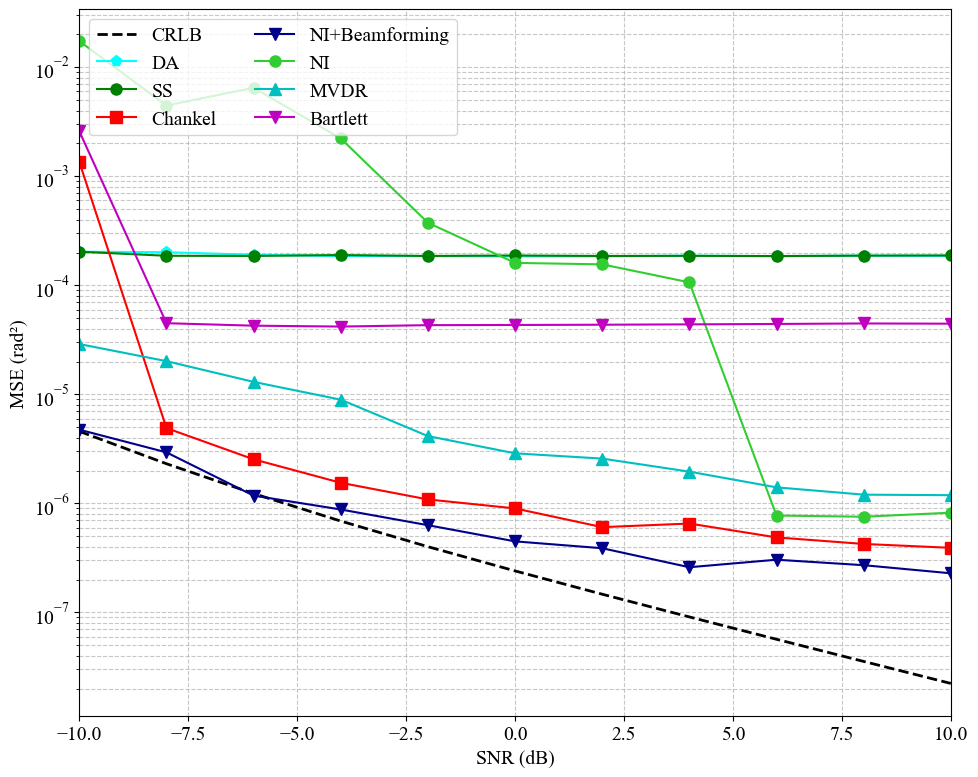

In [5]:
# Plot MSE vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['mse'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='MSE',
    parameter_unit='dB',
    metric_unit='rad²',
    crb_label='CRLB',
    crb_values=crb_snr_values,
    show_crb=True,
    ax=ax
    )
plt.tight_layout()
plt.show()

## 7. CDF Comparison

In [7]:
# Let's generate scatter plots for all algorithms
# We'll use SNR=10 dB with 256 snapshots

print('Generating scatter plots for all algorithms...')

sample_snr = -10.0  # SNR in dB
sample_n_snapshots = 1024  # Number of snapshots
sample_n_monte_carlo = 1000  # Number of Monte Carlo runs for sample generation

# Run performance evaluation with save_sample_estimates=True
sample_result = perf.evaluate_performance(
    array=array,
    sources=sources,
    snr=sample_snr,
    n_snapshots=sample_n_snapshots,
    n_monte_carlo=sample_n_monte_carlo,
    estimators=estimators,
    metrics=['mse', 'bias'],
    save_sample_estimates=True,
    n_jobs=1,
    verbose=1,
    power_source=4.0
    )

print(f'Generated sample estimates for: {list(sample_result.sample_estimates.keys())}')

Generating scatter plots for all algorithms...


Evaluating estimators: 100%|██████████| 7000/7000 [00:27<00:00, 255.00it/s] 

Generated sample estimates for: ['DA', 'SS', 'Chankel', 'NI+Beamforming', 'NI', 'MVDR', 'Bartlett']


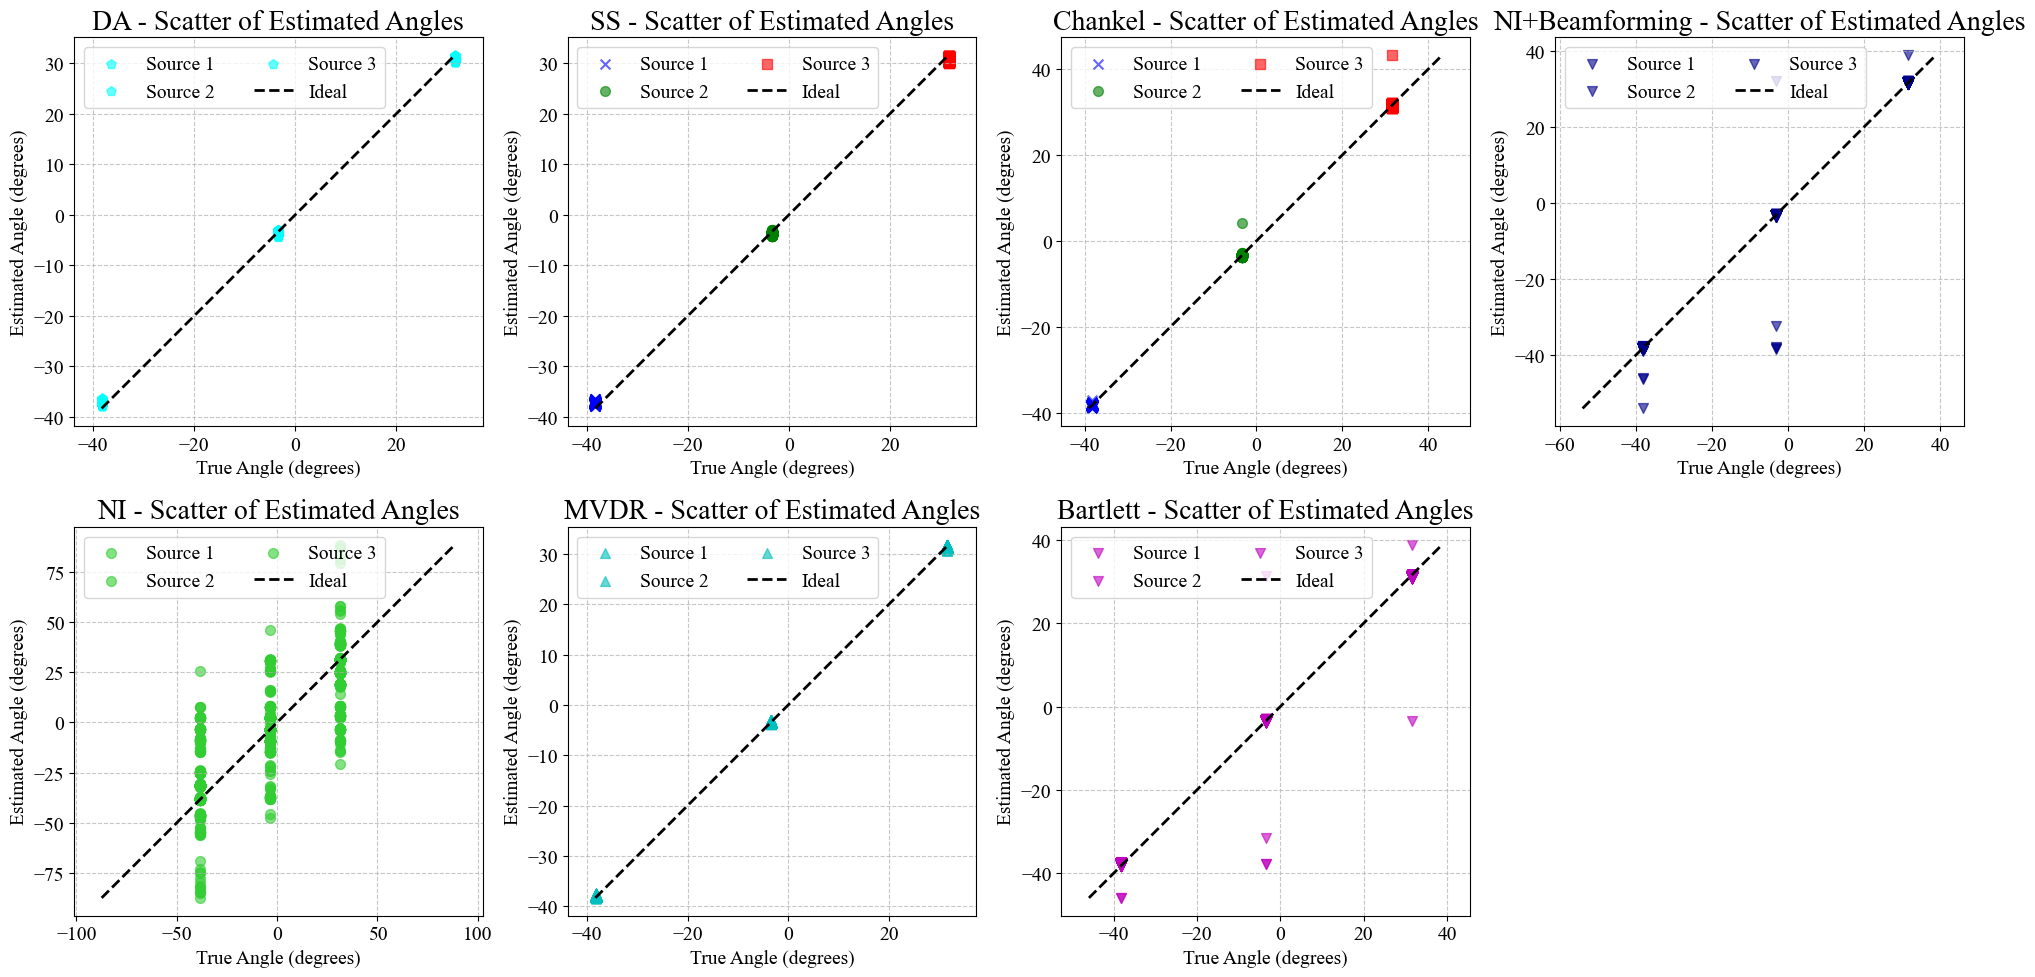

In [8]:
import math
# Plot scatter plot for each algorithm
n_algs = len(sample_result.sample_estimates)
n_cols = 4
n_rows = math.ceil(n_algs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (alg_name, estimates) in enumerate(sample_result.sample_estimates.items()):
    ax = axes[i]
    plt_tools.plot_scatter_estimates(
        true_angles=source_angles,
        estimates=estimates,
        algorithm_name=alg_name,
        angle_unit='deg',
        ax=ax
    )
    ax.set_title(f'{alg_name} - Scatter of Estimated Angles', fontsize=20)

# 隐藏多余的子图
for j in range(n_algs, len(axes)):
    axes[j].set_visible(False)

# plt.suptitle('Scatter Distributions of SDP Coarray Reconstruction Algorithms', fontsize=24, y=0.98)
plt.tight_layout()
plt.show()

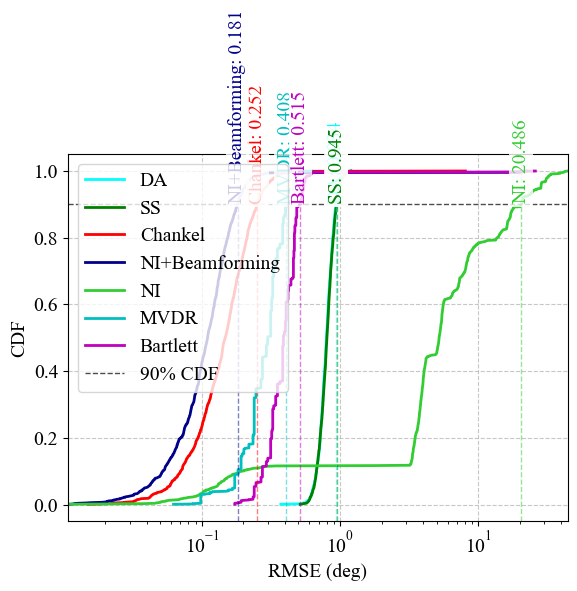

In [9]:
# Plot CDFs of RMS Error for all algorithms
fig, ax = plt.subplots(figsize=(6, 6))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,    
    true_angles=source_angles,
    metric_name='RMSE',
    metric_unit='deg',
    metric_type='rms',
    ax=ax,
    show_90_percentile=True
    )
# 添加90%的线

# plt.title('CDF of RMS Error for SDP Coarray Reconstruction Algorithms', fontsize=20)
ax.set_xscale('log')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Compute Time

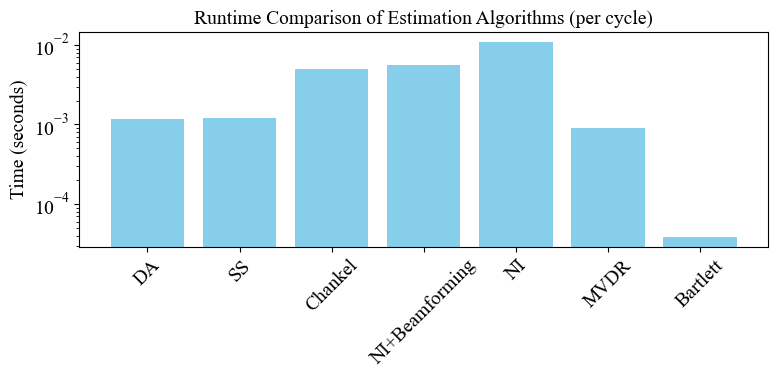

In [10]:
import matplotlib.pyplot as plt

# 提取时间字典
times = sample_result.estimator_times

# 可视化各算法耗时
plt.figure(figsize=(8, 4))
algorithms = list(times.keys())
values = [float(times[k]) for k in algorithms]

plt.bar(algorithms, values, color='skyblue')
plt.ylabel('Time (seconds)')
plt.yscale('log')
plt.title('Runtime Comparison of Estimation Algorithms (per cycle)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

